In [7]:
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

BASE        = Path(r"C:\Users\NIAMBELE Siata\Desktop\MSPR2")
MODELS_DIR  = BASE / "04_outputs" / "models"
MASTER_CSV  = BASE / "03_processed" / "master_ml.csv"

le_combined = joblib.load(MODELS_DIR / "le_combined.joblib")
X_combined  = joblib.load(MODELS_DIR / "X_combined.pkl")
y_combined  = joblib.load(MODELS_DIR / "y_combined.pkl")
X_train_c   = joblib.load(MODELS_DIR / "X_train_c.pkl")
X_test_c    = joblib.load(MODELS_DIR / "X_test_c.pkl")
y_train_c   = joblib.load(MODELS_DIR / "y_train_c.pkl")
y_test_c    = joblib.load(MODELS_DIR / "y_test_c.pkl")

print(f"y_combined shape : {y_combined.shape}")
print(f"X_combined shape : {X_combined.shape}")
print(f"Classes : {list(le_combined.classes_)}")

y_combined shape : (266,)
X_combined shape : (266, 154)
Classes : ['Centre', 'Droite', 'Extreme droite', 'Gauche']


In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# ETAPE 1 — Imputation manuelle avant SMOTE
# ==============================================================================
imputer = SimpleImputer(strategy="median")
X_imp_array = imputer.fit_transform(X_combined)

cols_conservees = X_combined.columns[
    X_combined.notna().any(axis=0)
].tolist()

X_imputed = pd.DataFrame(X_imp_array, columns=cols_conservees)

print(f"Colonnes initiales  : {X_combined.shape[1]}")
print(f"Colonnes conservées : {X_imputed.shape[1]}")
print(f"Colonnes supprimées : {X_combined.shape[1] - X_imputed.shape[1]}")
print(f"NaN restants        : {X_imputed.isna().sum().sum()}")

# ==============================================================================
# ETAPE 2 — SMOTE
# ==============================================================================
smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y_combined)

print(f"\nAvant SMOTE : {pd.Series(y_combined).value_counts().to_dict()}")
print(f"Après SMOTE : {pd.Series(y_resampled).value_counts().to_dict()}")
for cls_idx, cls_nom in zip(sorted(set(y_resampled)),
                             le_combined.inverse_transform(sorted(set(y_resampled)))):
    nb = (y_resampled == cls_idx).sum()
    print(f"  {cls_nom:<20} {nb} communes")

# ==============================================================================
# ETAPE 3 — Split
# ==============================================================================
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)
print(f"\nTrain : {len(X_train_bal)} | Test : {len(X_test_bal)}")

# ==============================================================================
# ETAPE 4 — Entraînement
# ==============================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modeles_bal = {
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=20,
            min_samples_split=5, min_samples_leaf=2,
            max_features="sqrt", class_weight="balanced",
            random_state=42, n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=5, subsample=0.8,
            min_samples_split=5, random_state=42
        ))
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1, penalty="l2", solver="lbfgs",
            max_iter=2000, class_weight="balanced",
            random_state=42, n_jobs=-1
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=5, weights="distance",
            metric="euclidean", n_jobs=-1
        ))
    ]),
}

bilan_bal = []
for nom, pipeline in modeles_bal.items():
    print(f"\nEntraînement : {nom}...")
    scores_cv = cross_val_score(
        pipeline, X_train_bal, y_train_bal,
        cv=skf, scoring="f1_weighted", n_jobs=-1
    )
    pipeline.fit(X_train_bal, y_train_bal)
    y_pred   = pipeline.predict(X_test_bal)
    acc      = accuracy_score(y_test_bal, y_pred)
    f1       = f1_score(y_test_bal, y_pred, average="weighted", zero_division=0)
    f1_macro = f1_score(y_test_bal, y_pred, average="macro",    zero_division=0)
    bilan_bal.append({
        "modele"     : nom,
        "accuracy"   : round(acc,      4),
        "f1_weighted": round(f1,       4),
        "f1_macro"   : round(f1_macro, 4),
        "score_cv"   : round(scores_cv.mean(), 4)
    })
    print(f"  Accuracy={acc:.3f} | F1w={f1:.3f} | F1macro={f1_macro:.3f} | CV={scores_cv.mean():.3f}")
    print(classification_report(
        y_test_bal, y_pred,
        target_names=le_combined.classes_,
        zero_division=0
    ))

df_bilan_bal = pd.DataFrame(bilan_bal).sort_values("f1_macro", ascending=False)
display(df_bilan_bal)

# ==============================================================================
# ETAPE 5 — Sauvegarde
# ← CORRECTION : on utilise cols_conservees, pas X_combined.columns
# ==============================================================================
meilleur_nom_bal    = df_bilan_bal.iloc[0]["modele"]
meilleur_modele_bal = modeles_bal[meilleur_nom_bal]

meilleur_bal_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf",     meilleur_modele_bal.named_steps["clf"])
])
meilleur_bal_final.fit(
    pd.DataFrame(X_resampled, columns=cols_conservees),  # ← cols_conservees
    y_resampled
)

joblib.dump(meilleur_bal_final, MODELS_DIR / "meilleur_modele_balanced.joblib")
joblib.dump(cols_conservees,    MODELS_DIR / "cols_conservees_balanced.pkl")
joblib.dump(df_bilan_bal,       MODELS_DIR / "df_bilan_balanced.pkl")

print(f"\nMeilleur modèle équilibré : {meilleur_nom_bal}")
print(f"Sauvegardé : meilleur_modele_balanced.joblib")

Colonnes initiales  : 154
Colonnes conservées : 142
Colonnes supprimées : 12
NaN restants        : 0

Avant SMOTE : {2: 187, 0: 41, 3: 26, 1: 12}
Après SMOTE : {2: 187, 3: 187, 1: 187, 0: 187}
  Centre               187 communes
  Droite               187 communes
  Extreme droite       187 communes
  Gauche               187 communes

Train : 598 | Test : 150

Entraînement : Random Forest...
  Accuracy=0.973 | F1w=0.973 | F1macro=0.974 | CV=0.948
                precision    recall  f1-score   support

        Centre       0.97      0.95      0.96        38
        Droite       0.97      1.00      0.99        37
Extreme droite       0.95      0.95      0.95        38
        Gauche       1.00      1.00      1.00        37

      accuracy                           0.97       150
     macro avg       0.97      0.97      0.97       150
  weighted avg       0.97      0.97      0.97       150


Entraînement : Gradient Boosting...
  Accuracy=0.973 | F1w=0.973 | F1macro=0.973 | CV=0.960
    

,modele,accuracy,f1_weighted,f1_macro,score_cv
0,Random Forest,0.9733,0.9732,0.9735,0.9477
1,Gradient Boosting,0.9733,0.9730,0.9731,0.9595
2,Logistic Regression,0.8933,0.8922,0.8925,0.9035
3,KNN,0.8733,0.8578,0.8587,0.8993



Meilleur modèle équilibré : Random Forest
Sauvegardé : meilleur_modele_balanced.joblib


In [10]:
# Rechargement pour les projections
meilleur_bal_final = joblib.load(MODELS_DIR / "meilleur_modele_balanced.joblib")
cols_conservees    = joblib.load(MODELS_DIR / "cols_conservees_balanced.pkl")

# Alignement de X_base sur les colonnes conservées
X_base_bal = X_base.reindex(columns=cols_conservees, fill_value=0)

print(f"X_base_bal shape : {X_base_bal.shape}")

X_base_bal shape : (266, 142)


Communes : 266

Probabilités moyennes par famille :
  Centre               0.013
  Droite               0.312
  Extreme droite       0.560
  Gauche               0.115

Distribution prédite :
famille_predite
Extreme droite    266

2025 (+1 an) (bruit=0.03)
  Centre               moy=0.019  IC=[0.000, 0.067]
  Droite               moy=0.310  IC=[0.261, 0.357]
  Extreme droite       moy=0.557  IC=[0.502, 0.615]
  Gauche               moy=0.114  IC=[0.060, 0.164]

2026 (+2 ans) (bruit=0.06)
  Centre               moy=0.029  IC=[0.000, 0.116]
  Droite               moy=0.306  IC=[0.209, 0.402]
  Extreme droite       moy=0.553  IC=[0.449, 0.670]
  Gauche               moy=0.112  IC=[0.005, 0.210]

2027 (+3 ans) (bruit=0.1)
  Centre               moy=0.042  IC=[0.000, 0.180]
  Droite               moy=0.299  IC=[0.136, 0.455]
  Extreme droite       moy=0.546  IC=[0.382, 0.737]
  Gauche               moy=0.112  IC=[0.000, 0.269]


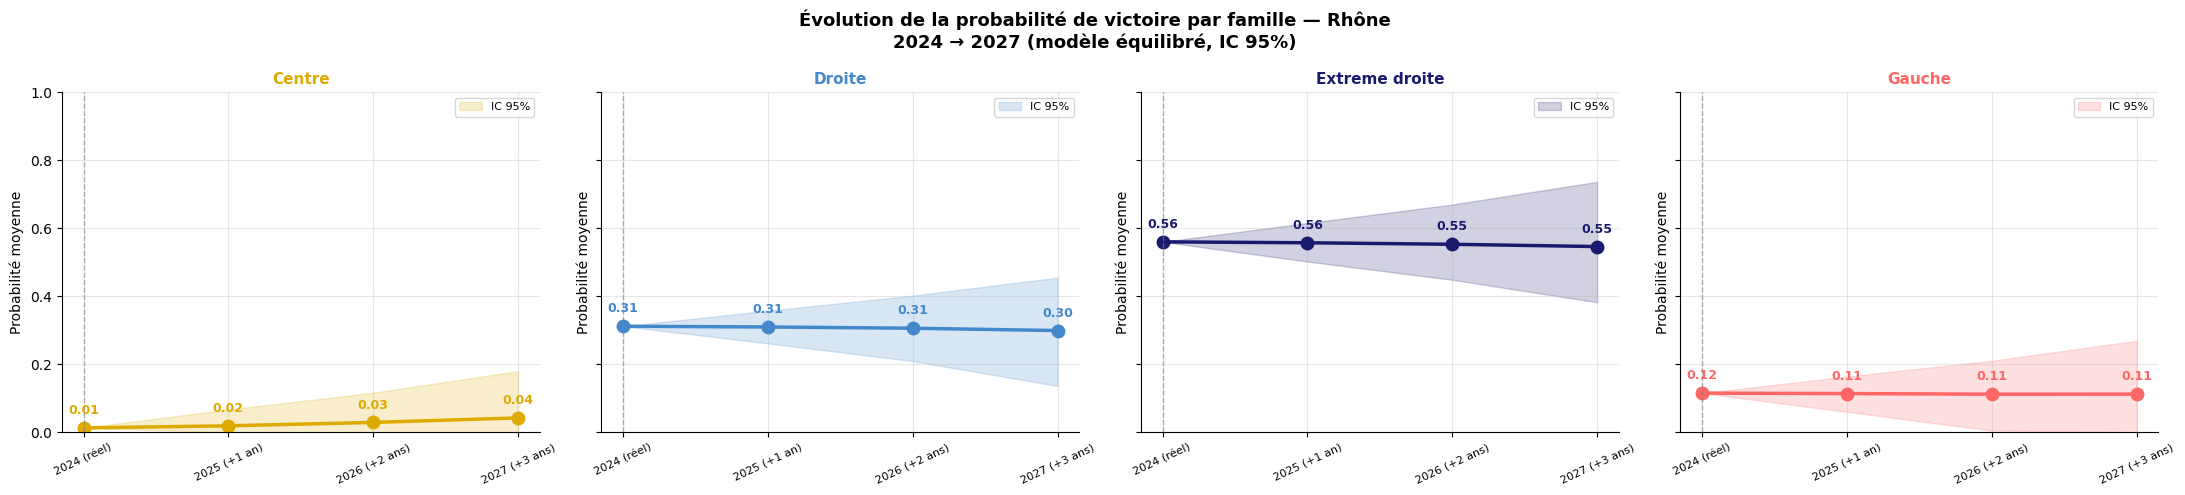

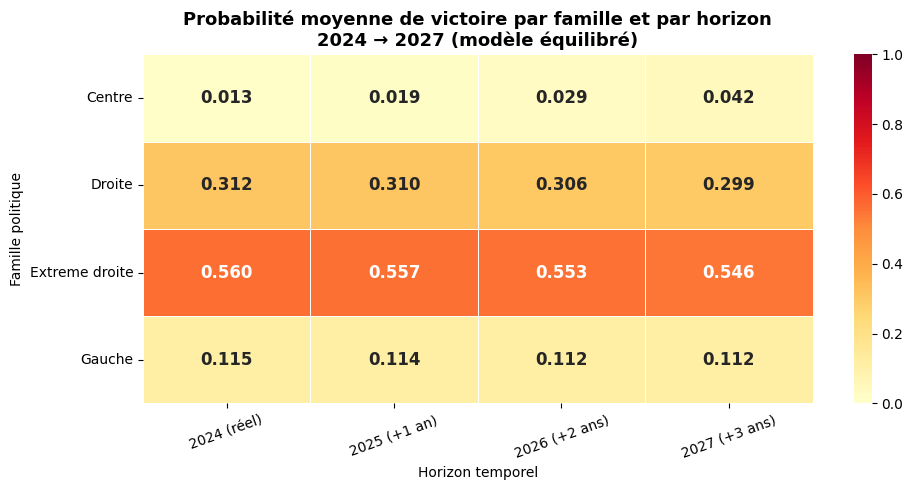

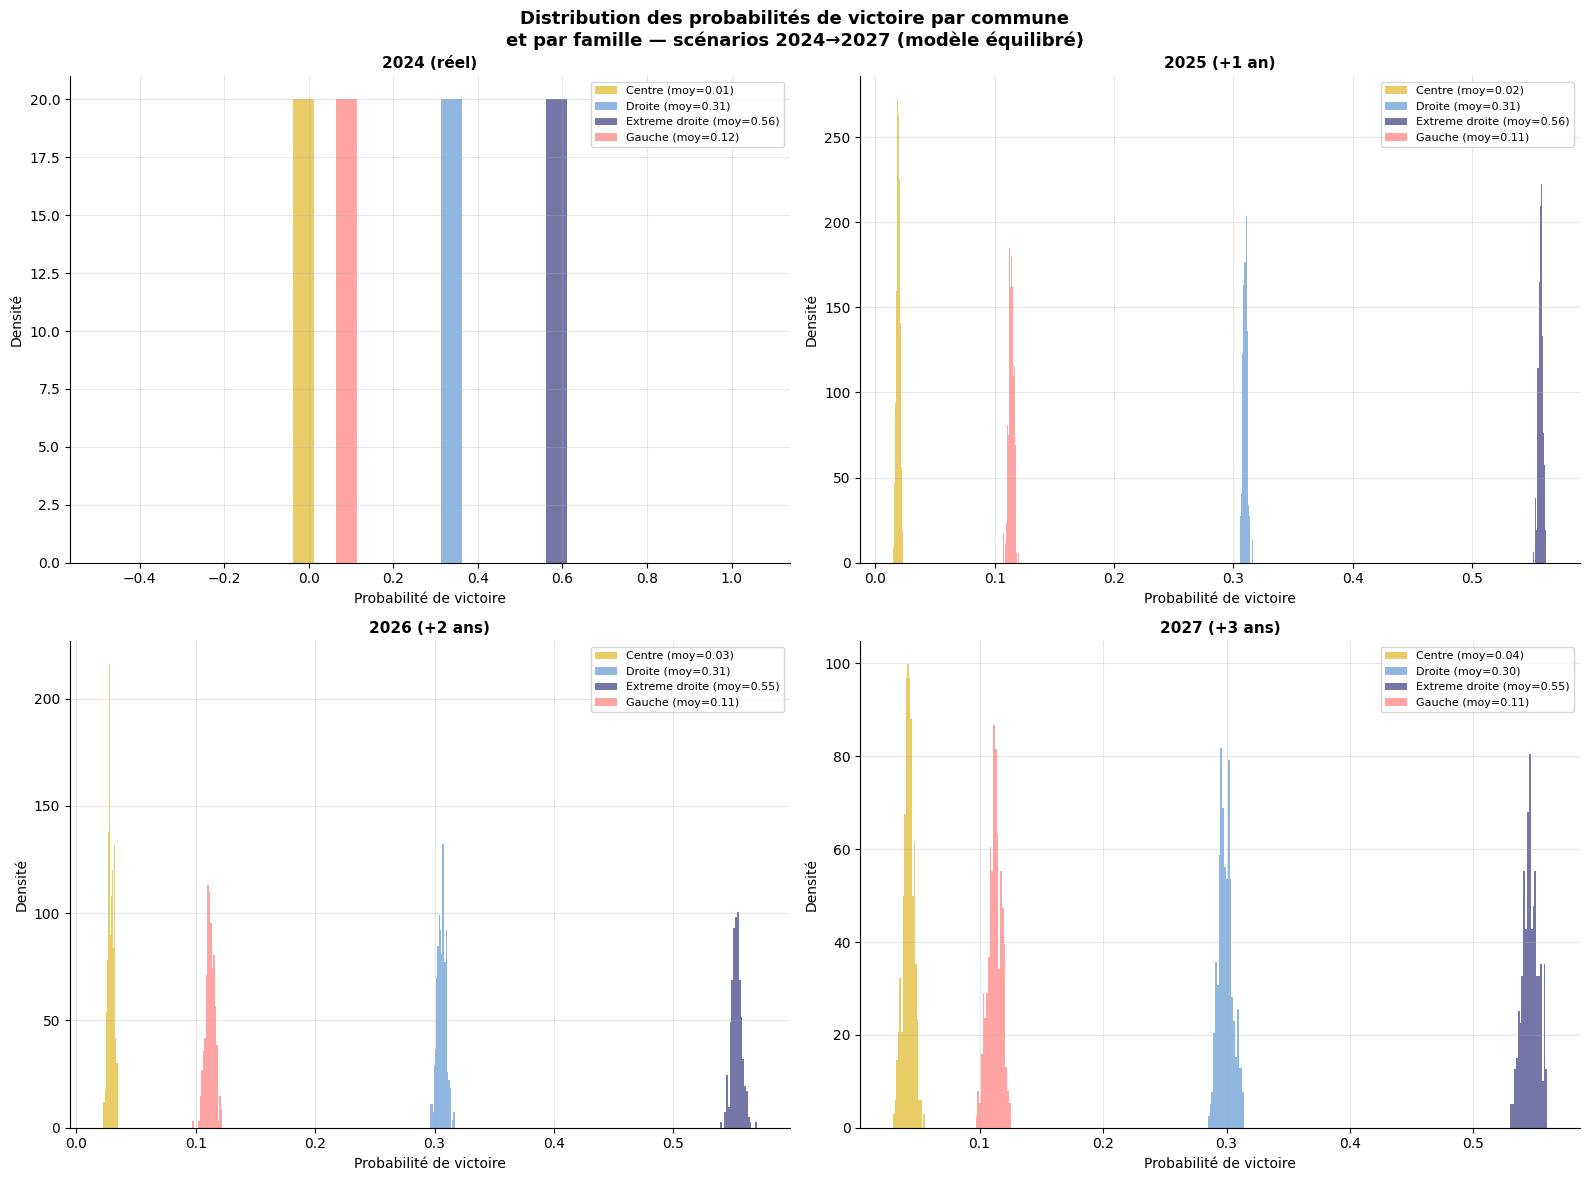

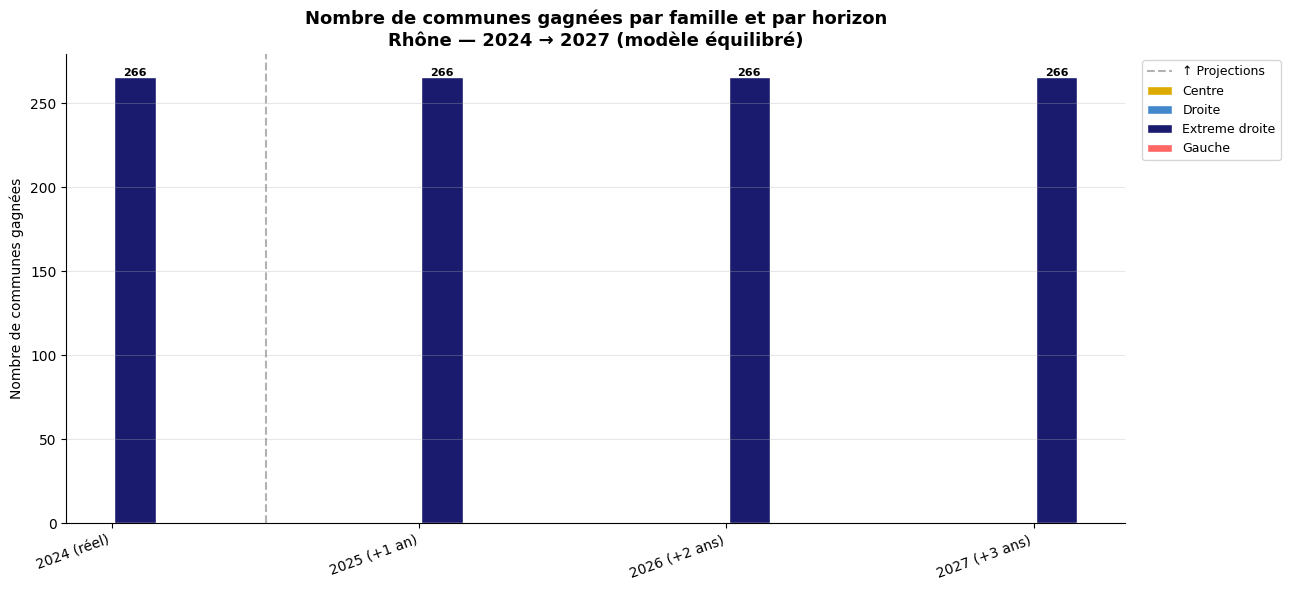


Projections équilibrées sauvegardées.

Résumé final :
                2024 (réel)  2025 (+1 an)  2026 (+2 ans)  2027 (+3 ans)
Centre                  NaN           NaN            NaN            NaN
Droite                  NaN           NaN            NaN            NaN
Extreme droite        266.0         266.0          266.0          266.0
Gauche                  NaN           NaN            NaN            NaN


In [11]:
# ==============================================================================
# PROJECTION AVEC MODELE EQUILIBRE
# ==============================================================================
probas = meilleur_bal_final.predict_proba(X_base_bal)
classes = le_combined.classes_

df_probas = pd.DataFrame(probas, columns=classes)
df_probas["code_commune"]    = df_2024["code_commune"].values
df_probas["famille_2024"]    = df_2024["famille_regroupee"].values
df_probas["famille_predite"] = le_combined.inverse_transform(np.argmax(probas, axis=1))

print(f"Communes : {len(df_probas)}")
print(f"\nProbabilités moyennes par famille :")
for c in classes:
    print(f"  {c:<20} {df_probas[c].mean():.3f}")

print(f"\nDistribution prédite :")
print(df_probas["famille_predite"].value_counts().to_string())

# ==============================================================================
# HORIZONS TEMPORELS
# ==============================================================================
np.random.seed(42)

horizons = {
    "2025 (+1 an)" : 0.03,
    "2026 (+2 ans)": 0.06,
    "2027 (+3 ans)": 0.10,
}

def projeter_probas(df_probas, classes, bruit_std, n_simulations=200):
    sims = []
    for _ in range(n_simulations):
        df_sim = df_probas[list(classes)].copy()
        bruit  = np.random.normal(0, bruit_std, df_sim.shape)
        df_sim = df_sim + bruit
        df_sim = df_sim.clip(0, 1)
        df_sim = df_sim.div(df_sim.sum(axis=1), axis=0)
        sims.append(df_sim.values)
    sims_array = np.array(sims)
    return sims_array.mean(axis=0), np.percentile(sims_array, 2.5, axis=0), np.percentile(sims_array, 97.5, axis=0)

resultats = {"2024 (réel)": {
    "moyenne": df_probas[list(classes)].values,
    "ic_bas" : df_probas[list(classes)].values,
    "ic_haut": df_probas[list(classes)].values,
}}

for label, bruit in horizons.items():
    moy, ic_b, ic_h = projeter_probas(df_probas, classes, bruit)
    resultats[label] = {"moyenne": moy, "ic_bas": ic_b, "ic_haut": ic_h}
    print(f"\n{label} (bruit={bruit})")
    for i, c in enumerate(classes):
        print(f"  {c:<20} moy={moy[:,i].mean():.3f}  IC=[{ic_b[:,i].mean():.3f}, {ic_h[:,i].mean():.3f}]")

# ==============================================================================
# VIZ 1 — Courbes temporelles
# ==============================================================================
annees = list(resultats.keys())
fig, axes = plt.subplots(1, len(classes), figsize=(22, 5), sharey=True)

for ax, famille in zip(axes, classes):
    idx      = list(classes).index(famille)
    moyennes = [resultats[a]["moyenne"][:, idx].mean() for a in annees]
    ic_bas   = [resultats[a]["ic_bas"][:,  idx].mean() for a in annees]
    ic_haut  = [resultats[a]["ic_haut"][:, idx].mean() for a in annees]

    ax.plot(annees, moyennes, "o-",
            color=COULEURS.get(famille, "#AAAAAA"),
            linewidth=2.5, markersize=9)
    ax.fill_between(annees, ic_bas, ic_haut,
                    alpha=0.2, color=COULEURS.get(famille, "#AAAAAA"),
                    label="IC 95%")
    ax.axvline(x="2024 (réel)", color="gray", linestyle="--", linewidth=1, alpha=0.6)
    for x_pos, y_pos in zip(annees, moyennes):
        ax.annotate(f"{y_pos:.2f}", (x_pos, y_pos),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, fontweight="bold",
                    color=COULEURS.get(famille, "#AAAAAA"))
    ax.set_title(famille, fontsize=11, fontweight="bold",
                 color=COULEURS.get(famille, "#AAAAAA"))
    ax.set_ylabel("Probabilité moyenne")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
    ax.grid(alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    ax.legend(fontsize=8)

plt.suptitle("Évolution de la probabilité de victoire par famille — Rhône\n2024 → 2027 (modèle équilibré, IC 95%)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "projection_bal_courbes.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================================================================
# VIZ 2 — Heatmap
# ==============================================================================
data_heatmap = {famille: [resultats[a]["moyenne"][:, list(classes).index(famille)].mean()
                           for a in annees]
                for famille in classes}
df_heat = pd.DataFrame(data_heatmap, index=annees).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_heat, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, linecolor="white",
            ax=ax, annot_kws={"size": 12, "weight": "bold"})
ax.set_title("Probabilité moyenne de victoire par famille et par horizon\n2024 → 2027 (modèle équilibré)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Horizon temporel")
ax.set_ylabel("Famille politique")
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "projection_bal_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================================================================
# VIZ 3 — Distribution des probabilités
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, horizon in enumerate(["2024 (réel)"] + list(horizons.keys())):
    ax  = axes[i]
    moy = resultats[horizon]["moyenne"]
    for j, famille in enumerate(classes):
        vals = moy[:, j]
        ax.hist(vals, bins=20, alpha=0.6,
                color=COULEURS.get(famille, "#AAAAAA"),
                label=f"{famille} (moy={vals.mean():.2f})",
                density=True)
    ax.set_title(horizon, fontsize=11, fontweight="bold")
    ax.set_xlabel("Probabilité de victoire")
    ax.set_ylabel("Densité")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Distribution des probabilités de victoire par commune\net par famille — scénarios 2024→2027 (modèle équilibré)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "projection_bal_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================================================================
# VIZ 4 — Communes gagnées par horizon
# ==============================================================================
communes_par_horizon = {}
for horizon, res in resultats.items():
    pred = le_combined.inverse_transform(np.argmax(res["moyenne"], axis=1))
    communes_par_horizon[horizon] = pd.Series(pred).value_counts()

df_communes = pd.DataFrame(communes_par_horizon).fillna(0).astype(int)
df_communes = df_communes.reindex(list(classes))

fig, ax = plt.subplots(figsize=(13, 6))
x     = np.arange(len(df_communes.columns))
width = 0.15

for i, famille in enumerate(df_communes.index):
    offset = (i - len(df_communes.index)/2) * width + width/2
    bars   = ax.bar(x + offset, df_communes.loc[famille],
                    width=width*0.9,
                    color=COULEURS.get(famille, "#AAAAAA"),
                    edgecolor="white", label=famille)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + 0.5, str(int(h)),
                    ha="center", fontsize=8, fontweight="bold")

ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=1.5,
           alpha=0.6, label="↑ Projections")
ax.set_xticks(x)
ax.set_xticklabels(df_communes.columns, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Nombre de communes gagnées")
ax.set_title("Nombre de communes gagnées par famille et par horizon\nRhône — 2024 → 2027 (modèle équilibré)",
             fontsize=13, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "projection_bal_communes.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nProjections équilibrées sauvegardées.")
print("\nRésumé final :")
print(df_communes.to_string())